In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from randomness import *
from simulation_exact import *
from utils import *
from data_analysis import *
from main import *
import numpy as np
import warnings
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
from joblib import Parallel, delayed
warnings.filterwarnings("ignore")
seed = 42
np.random.seed(seed)
rng = np.random.default_rng(seed)

In [3]:
def generate_data_d(n, mu1, mu2, rng, sigma = [1.0, 1.0], d=1):
    X1 = rng.normal(loc=mu1, scale=sigma[1], size=(n[1], d))
    X2 = rng.normal(loc=mu2, scale=sigma[0], size=(n[0], d))
    X = np.vstack([X1, X2])
    y = np.concatenate([
        -1 * np.ones(n[1]),
        np.ones(n[0])
    ])

    v = np.ones(n[0]+n[1])

    return X, y, v

In the block below, start by setting the parameters for the learning model  (lines 1-10 in block below)

experiments: (two blocks down )

1. to run the expirement for the same sample while changing mu_1 - mu_2, <br>
    remove the comments in lines 12 and 17 <br>
    comment line 16 <br>
    set T = 1 <br>

2. to run the expirement for the different samples and averaging over each T samples , <br>
    comments  lines 12 and 17 <br>
    remove comment line 16 <br>
    set T to be number of samples to be drawn per mu (line 12) <br>
 
In both cases you can choose parameters in lines 11-13, in the block below: <br>
    ds:= different dimensions to run the expierments on (line 11) <br>
    mus:= different mus to run the experiments on, where one distrbution has mean mu and the other has -mu (line 13)
    

In [ ]:
# 1. choose parameters 
n_pos = 50 # number of data points in a sample with label 1
n_neg = 50 # number of data points in a sample with label -1
n = [n_pos, n_neg]
sigma_pos = 1.0 # data sd for generating process 
sigma_neg = 1.0 # data sd for generating process 
sigma = [sigma_pos , sigma_neg] 
# ---------------------------------
use_loss = 'hinge' #'log' or 'hinge' or 'squared_hinge' 
sigma_loss = 1.0 
c = 1.0 # choose c without scaling 
show_plots = False # set to True to see plots of the binary search
is_throw = True # set to True to throw out points outside margin --> only when loss is lipschitz. 
#TODO: add is throw to outside_inside function 
k = None # if none will be set based on data max norm
k_coef = 1.0 # coefficient to multiply k with
fit_intercept = True # whether to fit intercept in SVM model
# ---------------------------------
ds = [2, 4, 8, 16, 32, 64] # dimensions to run experiments on
T = 50  # number of trials
mus = np.linspace(1.0, 0.0, 61) # different mus to run the experiments on


In [61]:
# 3. run exact simulation
# returns df with cols "agent" | "true_v" | "critical_v" | "allocation" | "welfare" | "utility"
# utility = welfare - payment
# welfare = allocation * true_v
# critical_v = payment 

def compute_metrics_d(d):#, k = None):
    # num_payers = np.zeros(len(mus))
    num_payers = {i: [] for i in range(len(mus))}
    sum_payments = {i: [] for i in range(len(mus))}
    acc = {i: [] for i in range(len(mus))}
    prc_relevant = {i: [] for i in range(len(mus))}

    for _ in range(T):
        #x, y, v = generate_data_d(n, mus[0], -mus[0], rng, sigma, d)
        for i, mu in enumerate(mus):
            x, y, v = generate_data_d(n, mu, -mu, rng, sigma, d)
            #x_updated = update_data(x, y, mu, -mu)
            df_exact, svm_model = run_exact(x, y, v, c, use_loss, sigma_loss=sigma_loss, plot=show_plots, 
                                    is_throw=is_throw, k=k, k_coef=k_coef, fit_intercept=fit_intercept)
    
            acc[i].append(svm_model.score(x,y))
            num_payers[i].append((df_exact['critical_v'] > 0).sum())
            sum_payments[i].append(df_exact['critical_v'].sum())
            prc_relevant[i].append( len(df_exact[df_exact['is_relevant'] == 1]) / len(df_exact))

    return d, {
        "num_payers": num_payers,
        "acc": acc,
        "sum_payments": sum_payments,
        "prc_relevant": prc_relevant,
    }


In [62]:
results = Parallel(n_jobs=-1, backend="loky")(
    delayed(compute_metrics_d)(d) for d in ds
)

results = dict(results) # map from d to metrics dict

/home/sadi.bana/bana_project/accuracy_limited_resource/main.py:324: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_exact = pd.concat([df_exact, pd.DataFrame([{
/home/sadi.bana/bana_project/accuracy_limited_resource/main.py:324: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_exact = pd.concat([df_exact, pd.DataFrame([{
/home/sadi.bana/bana_project/accuracy_limited_resource/main.py:324: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a futu

/home/sadi.bana/bana_project/accuracy_limited_resource/main.py:324: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_exact = pd.concat([df_exact, pd.DataFrame([{
/home/sadi.bana/bana_project/accuracy_limited_resource/main.py:324: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_exact = pd.concat([df_exact, pd.DataFrame([{
/home/sadi.bana/bana_project/accuracy_limited_resource/main.py:324: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a futu

/home/sadi.bana/bana_project/accuracy_limited_resource/main.py:324: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_exact = pd.concat([df_exact, pd.DataFrame([{
/home/sadi.bana/bana_project/accuracy_limited_resource/main.py:324: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_exact = pd.concat([df_exact, pd.DataFrame([{
/home/sadi.bana/bana_project/accuracy_limited_resource/main.py:324: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a futu

In [65]:
mus

array([1.        , 0.98333333, 0.96666667, 0.95      , 0.93333333,
       0.91666667, 0.9       , 0.88333333, 0.86666667, 0.85      ,
       0.83333333, 0.81666667, 0.8       , 0.78333333, 0.76666667,
       0.75      , 0.73333333, 0.71666667, 0.7       , 0.68333333,
       0.66666667, 0.65      , 0.63333333, 0.61666667, 0.6       ,
       0.58333333, 0.56666667, 0.55      , 0.53333333, 0.51666667,
       0.5       , 0.48333333, 0.46666667, 0.45      , 0.43333333,
       0.41666667, 0.4       , 0.38333333, 0.36666667, 0.35      ,
       0.33333333, 0.31666667, 0.3       , 0.28333333, 0.26666667,
       0.25      , 0.23333333, 0.21666667, 0.2       , 0.18333333,
       0.16666667, 0.15      , 0.13333333, 0.11666667, 0.1       ,
       0.08333333, 0.06666667, 0.05      , 0.03333333, 0.01666667,
       0.        ])

In [68]:
mean_acc

array([1.    , 1.    , 1.    , 1.    , 1.    , 1.    , 1.    , 1.    ,
       1.    , 1.    , 1.    , 1.    , 1.    , 1.    , 1.    , 1.    ,
       1.    , 1.    , 1.    , 1.    , 1.    , 1.    , 1.    , 1.    ,
       1.    , 1.    , 1.    , 1.    , 1.    , 1.    , 1.    , 1.    ,
       1.    , 1.    , 1.    , 0.9998, 1.    , 1.    , 1.    , 0.9988,
       0.9998, 0.9982, 0.9972, 0.9972, 0.9948, 0.9904, 0.989 , 0.9816,
       0.9724, 0.9646, 0.9562, 0.946 , 0.9298, 0.91  , 0.8938, 0.8714,
       0.8428, 0.8396, 0.8224, 0.8072, 0.791 ])

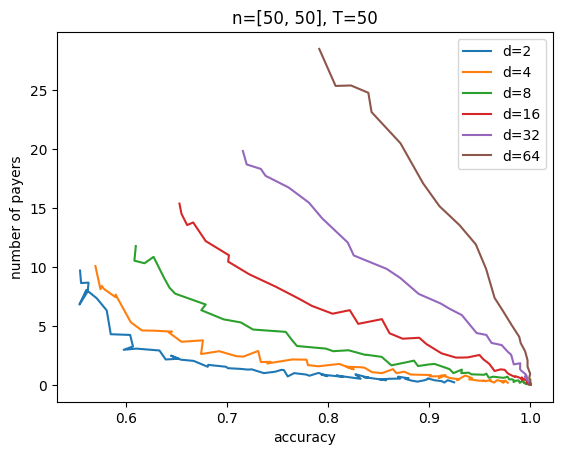

In [72]:
for d in results.keys():
    num_payers = results[d]["num_payers"]
    acc = results[d]["acc"]
    sum_payments = results[d]["sum_payments"]
    prc_relevant = results[d]["prc_relevant"]

    mean_num_payers = np.array([np.mean(num_payers[i]) for i in range(len(mus))])
    mean_sum_payments = np.array([np.mean(sum_payments[i]) for i in range(len(mus))])
    mean_acc = np.array([np.mean(acc[i]) for i in range(len(mus))])
    mean_prc_relevant = np.array([np.mean(prc_relevant[i]) for i in range(len(mus))])

    sd_num_payers = np.array([np.std(num_payers[i]) for i in range(len(mus))])
    sd_sum_payments = np.array([np.std(sum_payments[i]) for i in range(len(mus))])
    
    plt.plot(mean_acc, mean_num_payers, label=f"d={d}")
    # plt.plot(2*mus, mean_acc, label=f"Acc d={d}", linestyle='--')
    # plt.fill_between(2*mus, mean_num_payers - sd_num_payers, mean_num_payers + sd_num_payers, alpha=0.3)

plt.xlabel("accuracy")
plt.ylabel("number of payers")
plt.legend()
# plt.grid(True)
plt.title(f"n={n}, T={T}")
plt.show()

TODO: <br>
<ul>
     <li> add sd hue + </li>
     <li>add a change in sigma_data and n_data ++</li>
     <li>create micro notebook </li>
     <li>check for beta data </li>
</ul>

